# Worksheet 4 -- Linear Regression

In [147]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [148]:
df = pd.read_csv('data.csv', on_bad_lines='skip', header=13)
sample_A = df.dropna()
sample_A['pl_masse_err'] = (np.abs(sample_A['pl_masseerr1']) + np.abs(sample_A['pl_masseerr2'])) / 2.0

print("The new dataset has {} planets. Down from the original {}.".format(len(sample_A), len(df)))

The new dataset has 2914 planets. Down from the original 39803.


In [149]:
sample_B = sample_A[sample_A['pl_rade'] <= 5]
print(sample_B)

          pl_name  hostname  pl_rade  pl_masse  pl_masseerr1  pl_masseerr2  \
118      55 Cnc e    55 Cnc    2.173      8.37          0.38         -0.38   
120      55 Cnc e    55 Cnc    2.000      8.63          0.35         -0.35   
123      55 Cnc e    55 Cnc    1.875      7.99          0.32         -0.33   
125      55 Cnc e    55 Cnc    1.920      8.08          0.31         -0.31   
127      55 Cnc e    55 Cnc    1.910      8.08          0.31         -0.31   
...           ...       ...      ...       ...           ...           ...   
39569  Wolf 503 b  Wolf 503    2.043      6.26          0.69         -0.70   
39570  Wolf 503 b  Wolf 503    2.043      6.27          0.85         -0.84   
39742    pi Men c  HD 39091    2.060      4.52          0.81         -0.81   
39746    pi Men c  HD 39091    2.110      4.30          0.70         -0.70   
39749    pi Men c  HD 39091    2.042      4.82          0.84         -0.86   

       st_mass  pl_masse_err  
118      0.900         0.380  
1

Text(0, 0.5, 'Mass (Earth masses)')

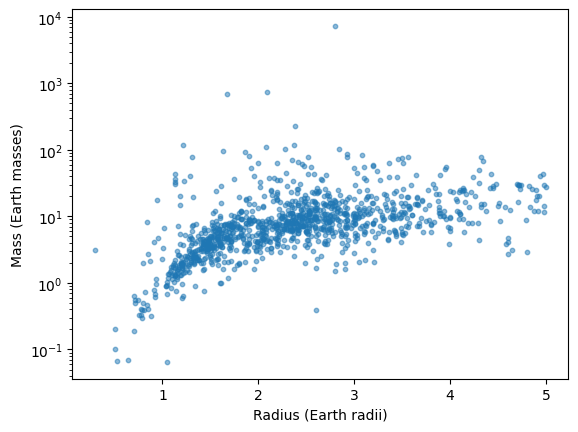

In [150]:
plt.scatter(sample_B['pl_rade'], sample_B['pl_masse'], alpha=0.5, s=10)
plt.yscale('log')
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')

In [151]:
# When all the uncertainties are the same, the least squares fit is equvalent to maximum likelihood estimate. We can use np.linalg.lstsq to find the best fit line.

# We are working in log space.
log_R = np.log10(sample_B['pl_rade'].values)
log_M = np.log10(sample_B['pl_masse'].values)

# lstsq expects a (M, N) array for the coefficient matrix.
X = np.column_stack([log_R, np.ones(len(log_R))])

x, residuals, rank, s = np.linalg.lstsq(X, log_M, rcond=None)
print(x, s)

[1.55177146 0.32619195] [35.80891981  5.75062427]


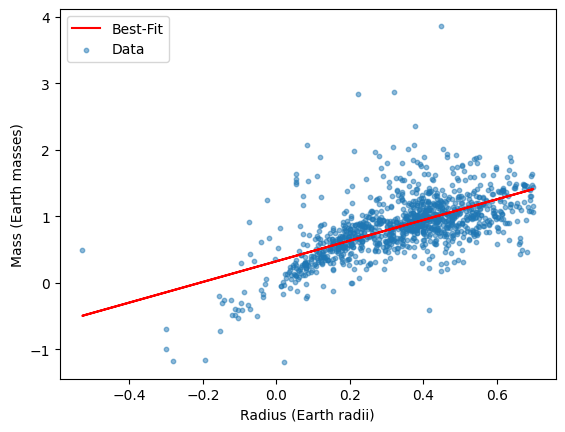

In [152]:
# Plot of best fit.
plt.plot(log_R, x[0] * log_R + x[1], label='Best-Fit', c='red')
plt.scatter(log_R, log_M, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [153]:
earth_radius_km = 6378.13
eath_mass_kg = 5.972e24

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

for name, data in solar_system.items():
    Radius = data['R_km'] / earth_radius_km        # Convert km → Earth radii
    log_Radius = np.log10(Radius)
    log_M_pred = x[0] * log_Radius + x[1]     # Apply the fitted model
    M_pred = 10**log_M_pred
    print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {data['M_true']:.3f}")

Mercury : predicted = 0.477, actual = 0.330
Venus   : predicted = 1.953, actual = 4.867
Earth   : predicted = 2.116, actual = 5.972
Mars    : predicted = 0.795, actual = 0.642
Jupiter : predicted = 87.057, actual = 1898.125
Saturn  : predicted = 65.557, actual = 568.317
Uranus  : predicted = 18.049, actual = 86.810
Neptune : predicted = 17.239, actual = 102.409


In [154]:
# Propagate uncertainties into log space
# σ(log10 M) ≈ σ_M / (M * ln(10))
sigma_logM = sample_B['pl_masse_err'].values / (sample_B['pl_masse'].values * np.log(10))

# In WLS, we weight each data point by 1/σ², so we divide by the uncertainty
# This is equivalent to MLE with Gaussian errors
weights = 1.0 / sigma_logM

# Build the weighted design matrix and target
X = np.column_stack([log_R, np.ones(len(log_R))])
X_w = X * weights[:, np.newaxis]    # Multiply each row by its weight
y_w = log_M * weights               # Multiply target by same weights

# Solve the weighted normal equations
x_2, residuals_2, rank_2, s_2 = np.linalg.lstsq(X_w, y_w, rcond=None)

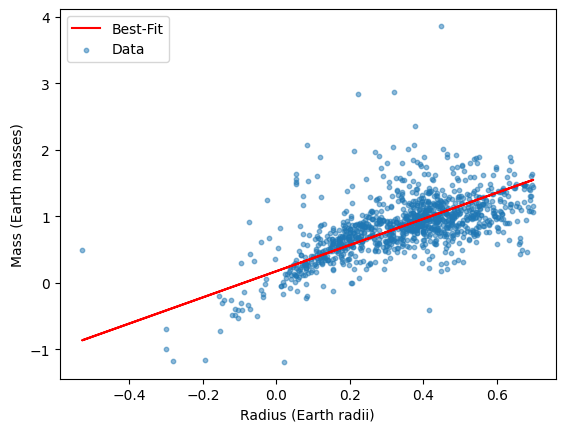

In [155]:
plt.plot(log_R, x_2[0] * log_R + x_2[1], label='Best-Fit', c='red')
plt.scatter(log_R, log_M, alpha=0.5, s=10, label="Data")
plt.xlabel('Radius (Earth radii)')
plt.ylabel('Mass (Earth masses)')
plt.legend(loc='upper left')

In [156]:
earth_radius_km = 6378.13
eath_mass_kg = 5.972e24

solar_system = {
    'Mercury': {'R_km': 2439.4, 'M_true': 0.330103},
    'Venus':   {'R_km': 6051.8, 'M_true': 4.86731},
    'Earth':   {'R_km': 6371.0084, 'M_true': 5.972},
    'Mars':    {'R_km': 3389.50, 'M_true': 0.641691},
    'Jupiter': {'R_km': 69911,  'M_true': 1898.125},
    'Saturn':  {'R_km': 58232,  'M_true': 568.317},
    'Uranus':  {'R_km': 25362,  'M_true': 86.8099},
    'Neptune': {'R_km': 24622,  'M_true': 102.4092},
}

for name, data in solar_system.items():
    Radius = data['R_km'] / earth_radius_km        # Convert km → Earth radii
    log_Radius = np.log10(Radius)
    log_M_pred = x_2[0] * log_Radius + x_2[1]     # Apply the fitted model
    M_pred = 10**log_M_pred
    print(f"{name:8s}: predicted = {M_pred:.3f}, actual = {data['M_true']:.3f}")

Mercury : predicted = 0.227, actual = 0.330
Venus   : predicted = 1.355, actual = 4.867
Earth   : predicted = 1.499, actual = 5.972
Mars    : predicted = 0.434, actual = 0.642
Jupiter : predicted = 166.164, actual = 1898.125
Saturn  : predicted = 116.016, actual = 568.317
Uranus  : predicted = 22.650, actual = 86.810
Neptune : predicted = 21.369, actual = 102.409
